Notebook to see which channel is used in which config file


In [152]:
import json
import pandas as pd
import glob
import os

def map_led_id():
    led_id_map = {}
    # print(glob.glob("/Users/nsallin/develop/data/2x2_LRS_runcontrol/LRS_det_config/pulser_config/Config/*.json"))
    for cfg_file in glob.glob("/Users/nsallin/develop/data/2x2_LRS_runcontrol/LRS_det_config/pulser_config/Config/*.json"):  # adjust path if needed
        filename = os.path.basename(cfg_file)
        with open(cfg_file) as f:
            data = json.load(f)

        # Step 2: Build led_id mapping
        for ch, (a, b) in data["channels"].items():
            if (a == 0 and b == 100):
                continue
            int_ch = int(ch[2:])
            led_id = f"1{int_ch+1:02d}{a:03d}{b:03d}"
            # ch_int = int(ch[2:])     
            # print(f"ch: {ch_int}, a: {a}, b:{b}, led_id:{led_id}")

            led_id_map[int(led_id)] = filename

    return led_id_map


In [153]:
led_id_map = map_led_id()
print(led_id_map)
# print(led_id_map['102120000'])

{102120000: '16.json', 101030000: '01.json', 104001035: '01.json', 105013000: '01.json', 107012000: '01.json', 109001018: '01.json', 111008000: '01.json', 113010000: '01.json', 115027000: '01.json', 102033000: '10.json', 104050000: '10.json', 110012000: '10.json', 112020044: '10.json', 114012000: '10.json', 102011000: '06.json', 104015000: '06.json', 105030000: '06.json', 107025000: '06.json', 110006000: '06.json', 112001020: '06.json', 114004000: '06.json', 116025000: '06.json', 102016000: '07.json', 104020000: '07.json', 105040000: '07.json', 107037000: '07.json', 110007000: '07.json', 112001025: '07.json', 114005000: '07.json', 116040000: '07.json', 102040000: '11.json', 104075000: '11.json', 110015000: '11.json', 112021044: '11.json', 114040000: '11.json', 101200000: '04.json', 104001046: '04.json', 105027000: '04.json', 107016000: '04.json', 109003000: '04.json', 111024000: '04.json', 113025000: '04.json', 116015000: '04.json', 102050000: '12.json', 104080000: '12.json', 110033000

In [154]:
# int_led_id_map = [int(key) for key in list(led_id_map.keys())]
print(sorted(list(led_id_map.keys())))
# print(sorted(int_led_id_map))

[101000000, 101030000, 101060000, 101100000, 101200000, 102011000, 102016000, 102020000, 102021000, 102033000, 102040000, 102050000, 102070000, 102080000, 102100000, 102120000, 104001035, 104001038, 104001040, 104001046, 104013000, 104015000, 104020000, 104022000, 104040000, 104050000, 104075000, 104080000, 105000000, 105013000, 105017000, 105025000, 105027000, 105029000, 105030000, 105040000, 106030000, 107012000, 107013000, 107014000, 107016000, 107023000, 107025000, 107037000, 107040000, 107065000, 109001018, 109001025, 109002000, 109003000, 110004000, 110006000, 110007000, 110008000, 110011000, 110012000, 110015000, 110033000, 110035000, 111008000, 111008010, 111010000, 111024000, 111025000, 112001020, 112001025, 112001030, 112001031, 112020044, 112021044, 112029000, 112030000, 113000000, 113010000, 113012000, 113013000, 113025000, 114004000, 114005000, 114006000, 114010000, 114012000, 114040000, 115027000, 116000000, 116008000, 116010000, 116015000, 116020000, 116025000, 116040000

In [186]:
import numpy as np

def map_chan_ledRun(led_id_map):
    path_moas = "/Users/nsallin/develop/data/2x2_LRS_runcontrol/LRS_det_config/moas_csv/MOAS_20251004_123836.csv"
    # Load MOAS
    moas = pd.read_csv(path_moas, usecols=["led_group_id_warm", "adc_nr", "adc_0in_chan", "tpc", "side", "side_chan"])

    map = np.full((8, 2, 24), 999)
    map_adc = np.full((8, 2, 24), 999)
    map_adc_chan = np.full((8, 2, 24), 999)

    led_ids = list(led_id_map.keys())

    for i, led_id in enumerate(moas["led_group_id_warm"]):
        
        if led_id in led_ids:
            # print(moas["tpc"][i], moas["side"][i], moas["side_chan"][i])
            # print(str(led_id))
            n_led_run = int(os.path.splitext(led_id_map[led_id])[0])
            map[int(moas["tpc"][i]), int(moas["side"][i]), int(moas["side_chan"][i])] = n_led_run
            map_adc[int(moas["tpc"][i]), int(moas["side"][i]), int(moas["side_chan"][i])] = int(moas["adc_nr"][i])
            map_adc_chan[int(moas["tpc"][i]), int(moas["side"][i]), int(moas["side_chan"][i])] = int(moas["adc_0in_chan"][i])
            # print(f'\nLED_ID: {led_id_map[str(led_id)]} for adc: {moas["adc_nr"][i]}, chan {moas["adc_0in_chan"][i]}, led_id: {led_id}')
            # print(f'\ntpc: {moas["tpc"][i]} for side: {moas["side"][i]}, chan {moas["side_chan"][i]}')
            # if i>10:
            #     return 0
        # else:
        #     print(f'\nNo LED_ID ({led_id}) for adc: {moas["adc_nr"][i]}, chan {moas["adc_0in_chan"][i]}')

    return map, map_adc, map_adc_chan


In [187]:
chan_ledRun_map, adc_ledRun_map, adc_chan_ledRun_map = map_chan_ledRun(led_id_map)

print(map[0,1,:])

[12 12 12 12 12 12  7  7  7  7  7  7  9  9  9  7  7  7  1  1  2  3  4  4]


In [188]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import matplotlib.cm as cm

def plot_map(chan_ledRun_map, adc_ledRun_map, adc_chan_ledRun_map):
    fig, axes = plt.subplots(2, 2, figsize=(14, 15))

    # Loop over subplots

    tpc_module = 0
    
    subplots_module_map = {0: 1, 1: 0, 2: 3, 3: 2}

    # Make a palette of 24 colors (using tab20 or any perceptual colormap)
    cmap = cm.get_cmap('tab20', 20)  
    palette = [cmap(i) for i in range(20)]

    for i_ax, ax in enumerate(axes.flat):
        ax.set_xlim(0, 3)
        ax.set_ylim(0, 48)
        ax.set_xticks([])
        ax.set_yticks([])

        # Draw left and right columns with reversed grouping pattern
        for col in [0, 2]:
            side = int(col/2)   
            y = 0
            cell_idx = 0
            tpc_module = 1
            
            pattern = [6, 2, 2, 2]
            while y < 48:
                for h in pattern:
                    if y + h > 48:  # don't exceed 48
                        h = 48 - y
                    rect = patches.Rectangle((col, y), 1, h, fill=False)
                    ax.add_patch(rect)
                    # Draw text for each cell individually
                    for t in range(h):
                        tpc = subplots_module_map[i_ax]*2+tpc_module
                        # ax.text(col + 0.5, y + t + 0.5, f"{tpc}, {side}, {cell_idx}",
                        #         ha='center', va='center', fontsize=6)
                        led_run = chan_ledRun_map[tpc,side,cell_idx]
                        if (led_run != 999):
                            color = palette[led_run]
                            rect = patches.Rectangle((col, y + t), 1, 1, facecolor=color, edgecolor='none', linewidth=0.1)
                            ax.add_patch(rect)
                        ax.text(col + 0.5, y + t + 0.5, f"LED Run: {led_run} (chan. {cell_idx}, adc {adc_ledRun_map[tpc,side,cell_idx]}, adc_chan {adc_chan_ledRun_map[tpc,side,cell_idx]})",
                                ha='center', va='center', fontsize=6)
                        cell_idx += 1
                    y += h
                    if y >= 48:
                        break
                    elif y == 24 or y == 0:
                        cell_idx = 0
                        tpc_module -= 1
                        rect = patches.Rectangle((col, y), 1, 24, fill=False, linewidth=2)
                        ax.add_patch(rect)

        # Draw middle column: two large cells (still from bottom)
        mid_heights = [24, 24]
        mid_y = 48
        for i, h in enumerate(mid_heights):
            rect = patches.Rectangle((1, mid_y-h), 1, h, fill=False, linewidth=2)
            ax.add_patch(rect)
            ax.text(1 + 0.5, mid_y - h/2, f"TPC {subplots_module_map[i_ax]*2+i}", ha='center', va='center', fontsize=8)
            mid_y -= h

        # Draw thicker outer borders
        ax.add_patch(patches.Rectangle((0,0),3,48, fill=False, linewidth=2))

        # Draw thicker middle vertical line
        ax.plot([1,1],[0,48], color='black', linewidth=2)

    plt.tight_layout()
    plt.show()

/var/folders/fy/3kj15xfx1ljgl63_qcp3vmb80000gn/T/ipykernel_30415/4269273673.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', 20)


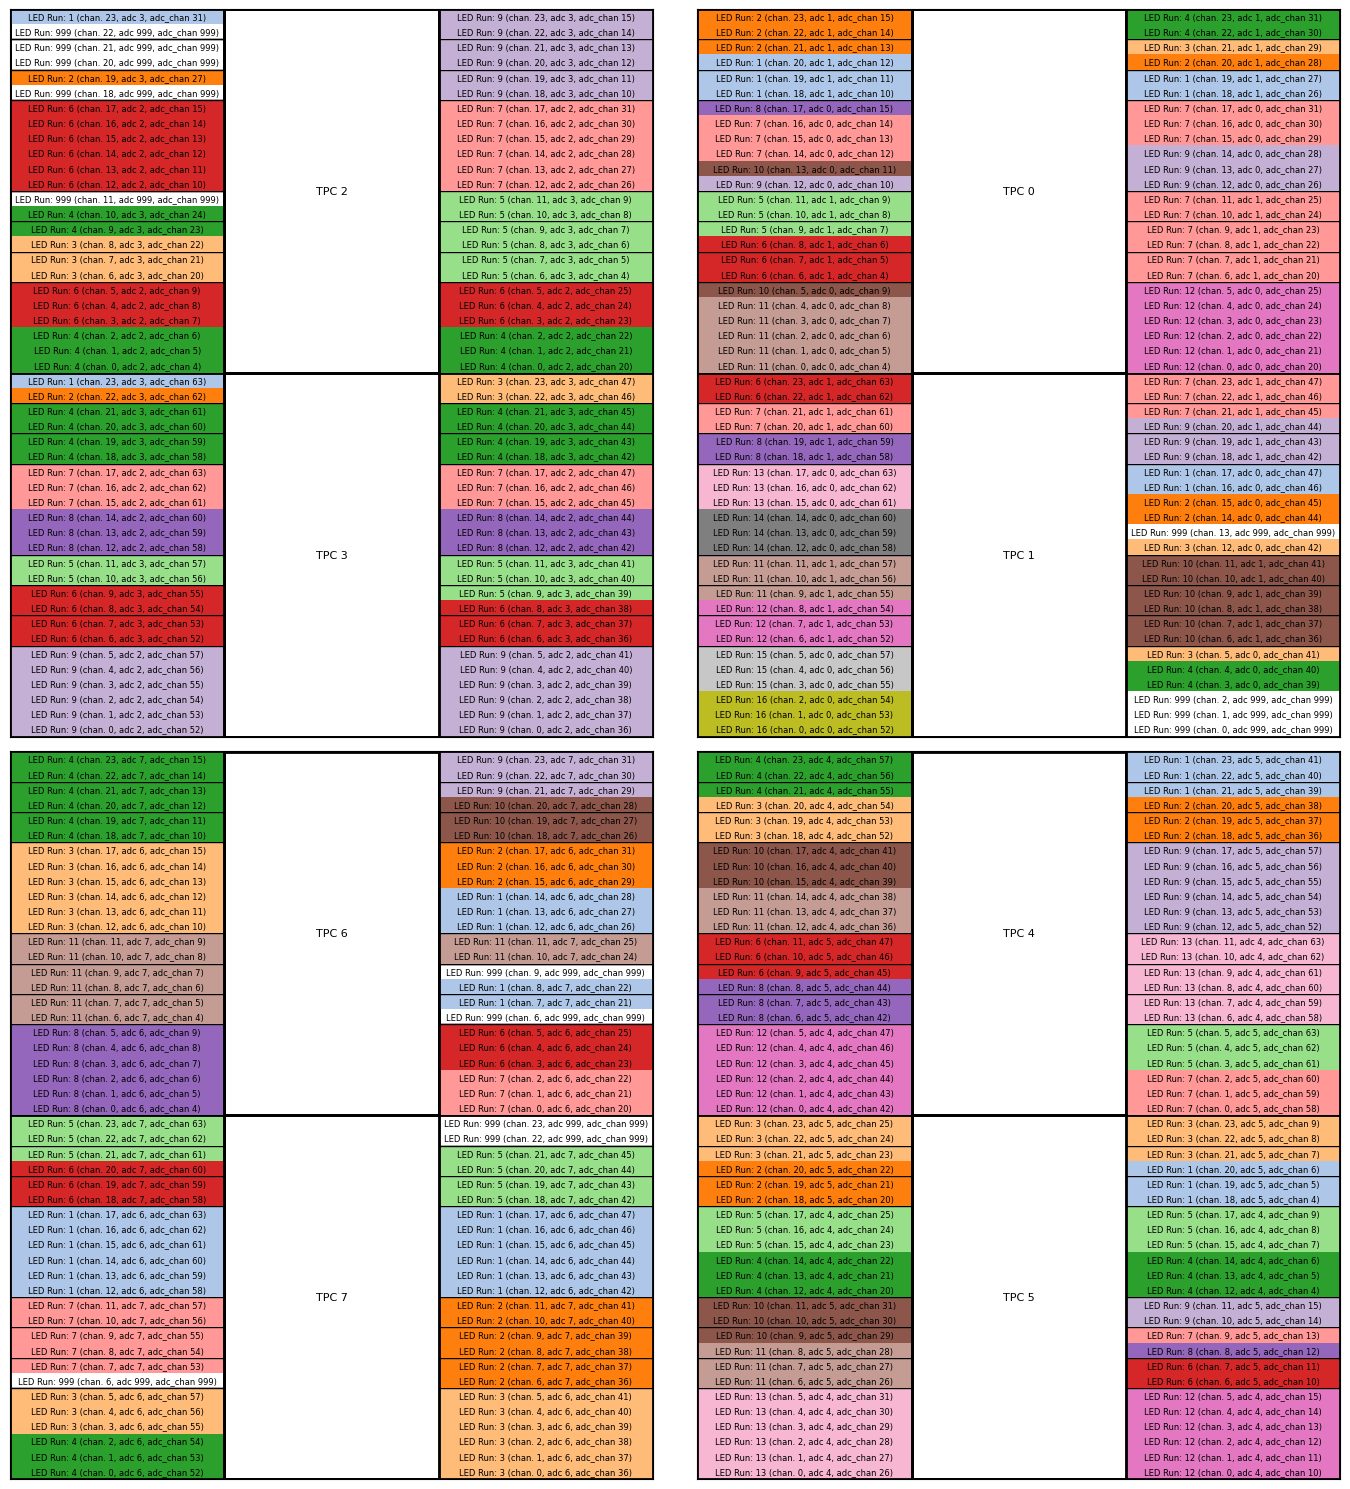

In [189]:
plot_map(chan_ledRun_map, adc_ledRun_map, adc_chan_ledRun_map)

In [190]:
def map_ledRun_PSsipm(led_id_map):
    path_moas = "/Users/nsallin/develop/data/2x2_LRS_runcontrol/LRS_det_config/moas_csv/MOAS_20251004_123836.csv"
    # Load MOAS
    moas = pd.read_csv(path_moas, usecols=["led_group_id_warm","vga_board_num", "sipm_bias_chan", "sipm_bias"])

    ledRun_PSsipm_map = {}

    led_ids = list(led_id_map.keys())

    for i, led_id in enumerate(moas["led_group_id_warm"]):
        
        if led_id in led_ids:
            n_led_run = int(os.path.splitext(led_id_map[led_id])[0])
            
            PS_sipm = [int(moas["vga_board_num"][i]), int(moas["sipm_bias_chan"][i]), float(moas["sipm_bias"][i])]
            ledRun_PSsipm_map.setdefault(n_led_run, []).append(PS_sipm)

    return ledRun_PSsipm_map

In [191]:
ledRun_PSsipm_map = map_ledRun_PSsipm(led_id_map)

run = ledRun_PSsipm_map
print(len(run), run)

16 {11: [[22, 81, 47.0], [22, 82, 47.0], [22, 83, 47.0], [22, 84, 47.0], [22, 85, 47.0], [22, 32, 47.0], [22, 33, 47.0], [22, 34, 47.0], [11, 81, 47.0], [11, 82, 47.0], [11, 83, 47.0], [11, 35, 47.0], [11, 36, 47.0], [11, 37, 47.0], [13, 41, 47.0], [13, 42, 47.0], [13, 43, 47.0], [13, 44, 47.0], [13, 45, 47.0], [13, 46, 47.0], [13, 57, 47.0], [13, 58, 47.0]], 10: [[22, 86, 47.0], [22, 88, 47.0], [22, 17, 47.0], [22, 18, 47.0], [22, 19, 47.0], [22, 20, 47.0], [22, 21, 47.0], [22, 22, 47.0], [11, 84, 47.0], [11, 85, 47.0], [11, 86, 47.0], [11, 38, 47.0], [11, 39, 47.0], [11, 40, 47.0], [13, 59, 47.0], [13, 60, 47.0], [13, 61, 47.0]], 9: [[22, 87, 47.0], [22, 99, 47.0], [22, 100, 47.0], [22, 101, 47.0], [22, 23, 47.0], [22, 24, 47.0], [22, 25, 47.0], [21, 81, 47.0], [21, 82, 47.0], [21, 83, 47.0], [21, 84, 47.0], [21, 85, 47.0], [21, 86, 47.0], [21, 93, 47.0], [21, 94, 47.0], [21, 95, 47.0], [21, 96, 47.0], [21, 97, 47.0], [21, 98, 47.0], [21, 59, 47.0], [21, 60, 47.0], [21, 61, 47.0], [2

In [ ]:
import os
import shutil

def make_sipmPS_config(map):
    
    output_path = "/Users/nsallin/develop/data/2x2_LRS_runcontrol/LRS_det_config/sipmps_config/test/"  # change to your actual output path

    NchanPS = 128
    indices = np.arange(1,NchanPS+1)
    Off_V = 1 # V

    # Delete the output_path folder if it exists
    if os.path.exists(output_path):
        shutil.rmtree(output_path)

    for nRun, PSchans in map.items():

        # Create folder for the key
        folder_path = os.path.join(output_path, str(nRun))
        os.makedirs(folder_path, exist_ok=True)  # won't raise error if folder exists
        
        print(f"Folder created: {folder_path}")

        mod0 = np.full(NchanPS, Off_V, dtype=float)
        mod1 = np.full(NchanPS, Off_V, dtype=float)
        mod2 = np.full(NchanPS, Off_V, dtype=float)
        mod3 = np.full(NchanPS, Off_V, dtype=float)
        
        for PSchan in PSchans:
            # print(PSchan)
            if PSchan[0] == 22:
                mod0[PSchan[1]-1]= PSchan[2]
            elif PSchan[0] == 21:
                mod1[PSchan[1]-1]= PSchan[2]
            elif PSchan[0] == 11:
                mod2[PSchan[1]-1]= PSchan[2]
            elif PSchan[0] == 13:
                mod3[PSchan[1]-1]= PSchan[2]

        
        mod0_wChan = np.column_stack((indices, mod0))
        mod1_wChan = np.column_stack((indices, mod1))
        mod2_wChan = np.column_stack((indices, mod2))
        mod3_wChan = np.column_stack((indices, mod3))

        np.savetxt(os.path.join(folder_path,"mod0.csv"), mod0_wChan, delimiter=",", fmt=["%d", "%.2f"])
        np.savetxt(os.path.join(folder_path,"mod1.csv"), mod1_wChan, delimiter=",", fmt=["%d", "%.2f"])
        np.savetxt(os.path.join(folder_path,"mod2.csv"), mod2_wChan, delimiter=",", fmt=["%d", "%.2f"])
        np.savetxt(os.path.join(folder_path,"mod3.csv"), mod3_wChan, delimiter=",", fmt=["%d", "%.2f"])

        # return 0  

        

In [ ]:
make_sipmPS_config(ledRun_PSsipm_map)

#TODO test with a moas not at 1V and add csv mod 1 2 3, remove return 0 for the other LED run and implement in start-run-calib

Folder created: /Users/nsallin/develop/data/2x2_LRS_runcontrol/LRS_det_config/sipmps_config/test/11
Folder created: /Users/nsallin/develop/data/2x2_LRS_runcontrol/LRS_det_config/sipmps_config/test/10
Folder created: /Users/nsallin/develop/data/2x2_LRS_runcontrol/LRS_det_config/sipmps_config/test/9
Folder created: /Users/nsallin/develop/data/2x2_LRS_runcontrol/LRS_det_config/sipmps_config/test/7
Folder created: /Users/nsallin/develop/data/2x2_LRS_runcontrol/LRS_det_config/sipmps_config/test/8
Folder created: /Users/nsallin/develop/data/2x2_LRS_runcontrol/LRS_det_config/sipmps_config/test/12
Folder created: /Users/nsallin/develop/data/2x2_LRS_runcontrol/LRS_det_config/sipmps_config/test/4
Folder created: /Users/nsallin/develop/data/2x2_LRS_runcontrol/LRS_det_config/sipmps_config/test/3
Folder created: /Users/nsallin/develop/data/2x2_LRS_runcontrol/LRS_det_config/sipmps_config/test/2
Folder created: /Users/nsallin/develop/data/2x2_LRS_runcontrol/LRS_det_config/sipmps_config/test/1
Folder 

In [ ]:
import sys
# import prettytable
sys.path.append("/Users/nsallin/develop/2x2_RunControl/2x2_LRS_runcontrol/")  

import lrsctrl.config as ctrl_config

ModuleNotFoundError: No module named 'prettytable'

In [2]:
# run_info = config.Run_Info()
print(dir(config))
print(config.__file__)

NameError: name 'config' is not defined

In [4]:
run_info = config.Run_Info()

AttributeError: 'Config' object has no attribute 'get_active_moas'